# Notebook 15 — Opponent Profiles: Archetypes, Strength Ratings & Position Heatmaps

**Goal:** Build the offline opponent profile database for the robot's strategy layer.

Three outputs:
1. **Archetype assignment** — classify each bot into one of 9 named archetypes
2. **Strength rating** — per-bot win-rate normalized to [0, 1]
3. **Position advantage heatmap** — per-archetype quarter-field grid showing where our robot should be

These will be hardcoded into the robot's Java lookup table (`OpponentProfileData.java`),
indexed by `OPPONENT_BOT_ID_HASH`.

### Archetypes

| # | Name | Key traits |
|---|---|---|
| 0 | UNRECOGNIZED | Default for unknown bots |
| 1 | ELITE_SURFER_STABLE | Smooth wave surfer, minimal adaptation (BeepBoop, Diamond) |
| 2 | ELITE_SURFER_ADAPTIVE | Wave surfer, adapts between rounds (DrussGT, Shadow) |
| 3 | STOP_AND_GO | Stops on fire detection, oscillates (ScalarR) |
| 4 | ORBITAL_AGGRESSIVE | Orbits, closes distance, high fire rate |
| 5 | ORBITAL_DEFENSIVE | Orbits, maintains range, conservative |
| 6 | RANDOM_MOVER | Erratic, no periodic structure |
| 7 | WALL_HUGGER | Fights near walls |
| 8 | WEAK_SIMPLE | Minimal movement, tutorial-level |

### Terms explained

- **Archetype**: a behavioral category based on movement and firing patterns.
  Like classifying chess openings — each has known strengths and counter-strategies.
- **Strength rating**: how often this bot wins overall, normalized from 0 (always loses) to 1 (always wins).
- **Position heatmap**: a grid of the battlefield showing which positions give us an advantage.
  Think of it like a "good seats in a stadium" map — some positions are better than others,
  and it depends on who you're playing against.
- **Quarter-field symmetry**: the battlefield is a rectangle, so top-left behaves like bottom-right
  (mirror in both axes). We only need to compute 1/4 of the grid and mirror at runtime.

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from _loader import (
    build_robot_index, load_stratified, attach_battle_constants,
    numeric_feature_cols, drop_redundant_features, SCAN_META_COLS,
    CSV_ROOT_DEFAULT
)

# Load data — need ticks + scores for all bots
selection = build_robot_index(max_robots=50, battles_per_robot=5, seed=42)
ticks = load_stratified('ticks.csv', selection, row_frac=0.10, verbose=True)
scores = load_stratified('scores.csv', selection, verbose=True)

# Attach battle constants (includes opponent identity hashes)
ticks = attach_battle_constants(ticks, scores)
print(f"Ticks: {len(ticks):,} rows, {len(ticks.columns)} columns")
print(f"Scores: {len(scores):,} rows")

Indexed 1942 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~5 battles = 250 (battle, robot) pairs to load.


Loaded 250 ticks.csv files → 845,052 rows × 87 cols, 50 robots (~356.9 MB)


Loaded 250 scores.csv files → 8,750 rows × 17 cols, 50 robots (~1.5 MB)


Ticks: 845,052 rows, 94 columns
Scores: 8,750 rows


## 1. Strength Ratings

Compute per-bot win rate from scores.csv. Normalize to [0, 1].

In [2]:
# Compute per-bot win rate from scores
# Each row in scores has win_rate for a perspective — use the last round's value per battle
if 'robot_name' not in scores.columns:
    from _loader import attach_opponent_bot
    scores = attach_opponent_bot(scores, selection)

# Get win rate per (battle, observer) — take last round's cumulative win_rate
battle_results = scores.groupby(['battle_id', 'robot_name']).agg(
    win_rate=('win_rate', 'last'),
    rounds=('win_rate', 'count')
).reset_index()

# Average win rate per bot across all battles
bot_strength = battle_results.groupby('robot_name').agg(
    mean_win_rate=('win_rate', 'mean'),
    n_battles=('win_rate', 'count')
).sort_values('mean_win_rate', ascending=False)

print("=== Bot Strength Ratings (top 15) ===")
print(bot_strength.head(15).to_string())
print(f"\n... {len(bot_strength)} bots total")

# Normalize to [0, 1]
bot_strength['strength'] = bot_strength['mean_win_rate']

=== Bot Strength Ratings (top 15) ===
                             mean_win_rate  n_battles
robot_name                                           
BeepBoop 2.0                       0.96570          5
ScalarR 0.005h.053-noshield        0.90858          5
Firestarter 2.0f                   0.79226          5
Knight 0.6.28                      0.78284          5
DrussGT 3.1.7                      0.77360          5
Dookious 1.573c                    0.71430          5
Combat 3.25.0                      0.71192          5
WhiteFang 2.8.1                    0.69144          5
Roborio 1.2.4                      0.64000          5
GresSuffurd 0.4.13                 0.62858          5
Pris 0.92                          0.62066          5
Neuromancer 7.12                   0.61342          5
Tomcat 3.68                        0.60002          5
Holden 1.13a                       0.58856          5
Raven 3.56j8                       0.57716          5

... 50 bots total


## 2. Behavioral Feature Extraction for Archetype Assignment

Extract per-bot behavioral features from ticks.csv:
- Movement: lateral velocity std, heading delta variability, direction change interval
- Firing: mean fire power, fire rate, power variability
- Positioning: mean distance, wall distance, center distance
- Adaptation signal: cross-round KS distance (from nb09 if available)

In [3]:
# Per-bot behavioral profiles from ticks data
# We need: opponent_bot column to know WHO is being observed
if 'opponent_bot' not in ticks.columns:
    from _loader import attach_opponent_bot
    ticks = attach_opponent_bot(ticks, selection)

# Features to profile: these describe the OPPONENT's behavior
# (we observe them via scan events)
profile_cols_available = [c for c in [
    'opponent_lateral_velocity', 'opponent_velocity',
    'opponent_heading_delta', 'opponent_velocity_delta',
    'opponent_is_decelerating', 'opponent_time_since_direction_change',
    'distance', 'opponent_dist_to_wall_min',
    'opponent_fired', 'opponent_fire_power',
    'opponent_angular_velocity',
    'opponent_heading_delta_variability_10',
    'opponent_velocity_variability_10',
    'opponent_avg_lateral_velocity_10',
] if c in ticks.columns]

print(f"Using {len(profile_cols_available)} behavioral columns for profiling")

# Aggregate per opponent bot
profiles = ticks.groupby('opponent_bot')[profile_cols_available].agg(['mean', 'std']).reset_index()
profiles.columns = ['_'.join(c).strip('_') for c in profiles.columns]

# Add derived features
if 'opponent_fired_mean' in profiles.columns:
    profiles['fire_rate'] = profiles['opponent_fired_mean']
if 'opponent_is_decelerating_mean' in profiles.columns:
    profiles['decel_fraction'] = profiles['opponent_is_decelerating_mean']
if 'opponent_time_since_direction_change_mean' in profiles.columns:
    profiles['mean_dir_change_interval'] = profiles['opponent_time_since_direction_change_mean']
if 'opponent_lateral_velocity_std' in profiles.columns:
    profiles['lat_vel_variability'] = profiles['opponent_lateral_velocity_std']
if 'opponent_heading_delta_variability_10_mean' in profiles.columns:
    profiles['heading_smoothness'] = profiles['opponent_heading_delta_variability_10_mean']
if 'opponent_dist_to_wall_min_mean' in profiles.columns:
    profiles['wall_proximity'] = profiles['opponent_dist_to_wall_min_mean']

print(f"Profiles for {len(profiles)} bots, {len(profiles.columns)} features")
profiles.head()

Using 14 behavioral columns for profiling
Profiles for 49 bots, 35 features


,opponent_bot,opponent_lateral_velocity_mean,opponent_lateral_velocity_std,opponent_velocity_mean,opponent_velocity_std,opponent_heading_delta_mean,opponent_heading_delta_std,opponent_velocity_delta_mean,opponent_velocity_delta_std,opponent_is_decelerating_mean,...,opponent_velocity_variability_10_mean,opponent_velocity_variability_10_std,opponent_avg_lateral_velocity_10_mean,opponent_avg_lateral_velocity_10_std,fire_rate,decel_fraction,mean_dir_change_interval,lat_vel_variability,heading_smoothness,wall_proximity
0,Ali 0.4.9,-0.146386,5.585162,0.035624,6.054288,-0.001588,0.056676,0.004862,1.023121,0.178886,...,1.649073,1.268584,-0.174263,5.250495,0.064621,0.178886,115.740471,5.585162,0.037216,56.815281
1,Ascendant 1.2.27,0.024760,5.743348,-0.018823,5.872892,0.000986,0.054543,0.006570,1.030741,0.241345,...,1.918015,1.267516,0.044453,5.239547,0.066399,0.241345,55.194683,5.743348,0.034500,138.633377
2,BeepBoop 2.0,-0.040691,4.698829,0.005285,4.873374,-0.000699,0.040032,0.003224,0.919240,0.303475,...,1.268800,1.267554,-0.027221,4.383253,0.076353,0.303475,19.577438,4.698829,0.020378,81.227097
3,BlackBox 0.0.2,-0.082539,5.632631,0.054270,5.699972,-0.000612,0.067808,0.009185,1.142075,0.234414,...,1.709546,1.169416,-0.069481,5.190004,0.072830,0.234414,44.187805,5.632631,0.046415,161.332123
4,CHCl3 1.4.2,-0.119468,5.787475,-0.117781,5.854207,-0.000495,0.061646,-0.024067,1.125623,0.225670,...,1.740520,1.185402,-0.084352,5.374951,0.068231,0.225670,43.835316,5.787475,0.039568,156.817764


## 3. K-Means Clustering → Archetype Assignment

Cluster bots into behavioral groups, then manually map clusters to named archetypes.
We use K=8 (excluding UNRECOGNIZED which is a runtime-only category).

In [4]:
# Select features for clustering
cluster_features = [c for c in [
    'lat_vel_variability', 'heading_smoothness', 'mean_dir_change_interval',
    'decel_fraction', 'fire_rate', 'wall_proximity',
    'distance_mean', 'opponent_velocity_mean',
] if c in profiles.columns]

print(f"Clustering on {len(cluster_features)} features: {cluster_features}")

X = profiles[cluster_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try K=5 through K=9 and pick best silhouette
from sklearn.metrics import silhouette_score

results = []
for k in range(3, 10):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append((k, sil))
    print(f"K={k}: silhouette={sil:.3f}")

best_k = max(results, key=lambda x: x[1])[0]
print(f"\nBest K={best_k}")

# Use K=8 as our target (matching the 8 named archetypes)
# If silhouette is poor at K=8, we'll merge clusters
km_final = KMeans(n_clusters=min(best_k, 8), n_init=50, random_state=42)
profiles['cluster'] = km_final.fit_predict(X_scaled)

Clustering on 8 features: ['lat_vel_variability', 'heading_smoothness', 'mean_dir_change_interval', 'decel_fraction', 'fire_rate', 'wall_proximity', 'distance_mean', 'opponent_velocity_mean']


K=3: silhouette=0.210
K=4: silhouette=0.175
K=5: silhouette=0.173
K=6: silhouette=0.192


K=7: silhouette=0.222
K=8: silhouette=0.193
K=9: silhouette=0.197

Best K=7


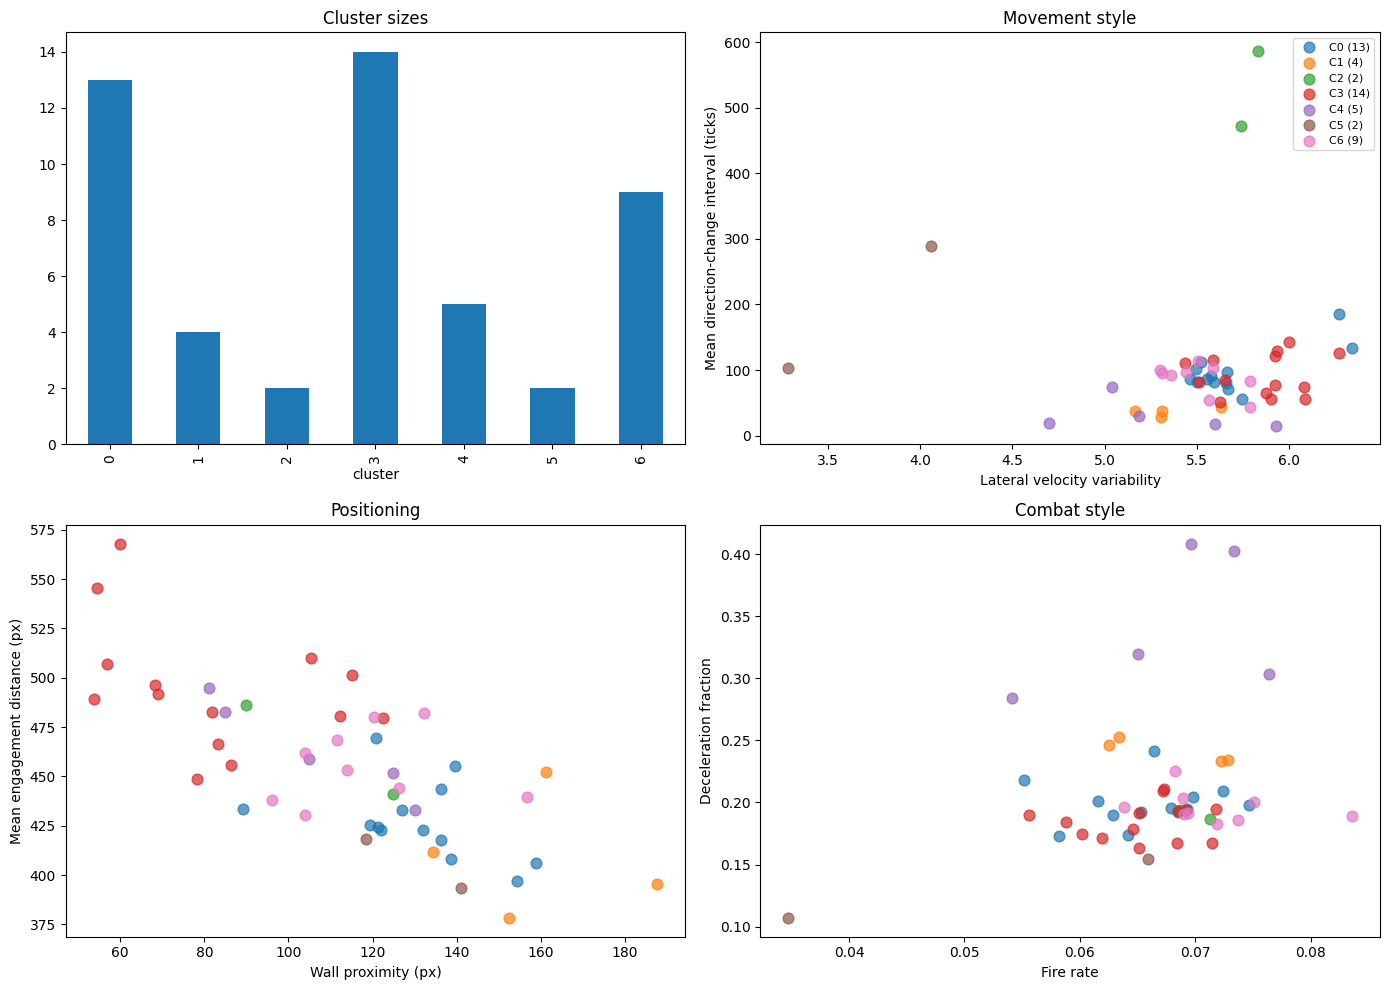

In [5]:
# Visualize clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster sizes
profiles['cluster'].value_counts().sort_index().plot.bar(ax=axes[0, 0], title='Cluster sizes')

# Lat velocity variability vs direction change interval
if 'lat_vel_variability' in profiles.columns and 'mean_dir_change_interval' in profiles.columns:
    for c in sorted(profiles['cluster'].unique()):
        mask = profiles['cluster'] == c
        axes[0, 1].scatter(
            profiles.loc[mask, 'lat_vel_variability'],
            profiles.loc[mask, 'mean_dir_change_interval'],
            label=f'C{c} ({mask.sum()})', alpha=0.7, s=60
        )
    axes[0, 1].set_xlabel('Lateral velocity variability')
    axes[0, 1].set_ylabel('Mean direction-change interval (ticks)')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].set_title('Movement style')

# Wall proximity vs distance
if 'wall_proximity' in profiles.columns and 'distance_mean' in profiles.columns:
    for c in sorted(profiles['cluster'].unique()):
        mask = profiles['cluster'] == c
        axes[1, 0].scatter(
            profiles.loc[mask, 'wall_proximity'],
            profiles.loc[mask, 'distance_mean'],
            label=f'C{c}', alpha=0.7, s=60
        )
    axes[1, 0].set_xlabel('Wall proximity (px)')
    axes[1, 0].set_ylabel('Mean engagement distance (px)')
    axes[1, 0].set_title('Positioning')

# Fire rate vs decel fraction
if 'fire_rate' in profiles.columns and 'decel_fraction' in profiles.columns:
    for c in sorted(profiles['cluster'].unique()):
        mask = profiles['cluster'] == c
        axes[1, 1].scatter(
            profiles.loc[mask, 'fire_rate'],
            profiles.loc[mask, 'decel_fraction'],
            label=f'C{c}', alpha=0.7, s=60
        )
    axes[1, 1].set_xlabel('Fire rate')
    axes[1, 1].set_ylabel('Deceleration fraction')
    axes[1, 1].set_title('Combat style')

plt.tight_layout()
plt.show()

In [6]:
# Print cluster contents with strength ratings
for c in sorted(profiles['cluster'].unique()):
    members = profiles[profiles['cluster'] == c]['opponent_bot'].tolist()
    print(f"\n=== Cluster {c} ({len(members)} bots) ===")
    for bot in sorted(members):
        strength = bot_strength.loc[bot, 'strength'] if bot in bot_strength.index else '?'
        if isinstance(strength, (float, np.floating)):
            print(f"  {bot:40s} strength={strength:.3f}")
        else:
            print(f"  {bot:40s} strength={strength}")


=== Cluster 0 (13 bots) ===
  Ascendant 1.2.27                         strength=0.400
  Dookious 1.573c                          strength=0.714
  Engineer 0.5.4                           strength=0.337
  Firebird 0.25                            strength=0.371
  Horizon 1.2.2                            strength=0.429
  Hydra 0.21                               strength=0.448
  Midboss 1q.fast                          strength=0.274
  Phoenix 1.02                             strength=0.457
  RougeDC willow                           strength=0.497
  SilverSurfer 2.53.33fix                  strength=0.368
  WaveSerpent 2.11                         strength=0.457
  Wintermute 0.8                           strength=0.427
  deBroglie rev0108                        strength=0.200

=== Cluster 1 (4 bots) ===
  BlackBox 0.0.2                           strength=0.354
  Holden 1.13a                             strength=0.589
  Pris 0.92                                strength=0.621
  YersiniaPesti

## 4. Manual Archetype Mapping

After inspecting the clusters above, map each cluster ID to a named archetype.
Edit the mapping below based on the cluster contents.

In [7]:
# ====================================================================
# EDIT THIS MAPPING after inspecting the clusters above!
# Map cluster ID → OpponentArchetype ordinal:
#   0=UNRECOGNIZED, 1=ELITE_SURFER_STABLE, 2=ELITE_SURFER_ADAPTIVE,
#   3=STOP_AND_GO, 4=ORBITAL_AGGRESSIVE, 5=ORBITAL_DEFENSIVE,
#   6=RANDOM_MOVER, 7=WALL_HUGGER, 8=WEAK_SIMPLE
# ====================================================================

ARCHETYPE_NAMES = [
    'UNRECOGNIZED',           # 0
    'ELITE_SURFER_STABLE',    # 1
    'ELITE_SURFER_ADAPTIVE',  # 2
    'STOP_AND_GO',            # 3
    'ORBITAL_AGGRESSIVE',     # 4
    'ORBITAL_DEFENSIVE',      # 5
    'RANDOM_MOVER',           # 6
    'WALL_HUGGER',            # 7
    'WEAK_SIMPLE',            # 8
]

# TODO: Fill this after inspecting clusters.
# cluster_to_archetype = {0: 4, 1: 1, 2: 6, ...}
cluster_to_archetype = {}

if cluster_to_archetype:
    profiles['archetype'] = profiles['cluster'].map(cluster_to_archetype)
    profiles['archetype_name'] = profiles['archetype'].map(lambda x: ARCHETYPE_NAMES[x])
    print("Archetype distribution:")
    print(profiles['archetype_name'].value_counts())
else:
    print("⚠ cluster_to_archetype mapping not yet filled in.")
    print("  Inspect the clusters above and assign each to an archetype ordinal.")
    # Placeholder: assign all to UNRECOGNIZED
    profiles['archetype'] = 0
    profiles['archetype_name'] = 'UNRECOGNIZED'

⚠ cluster_to_archetype mapping not yet filled in.
  Inspect the clusters above and assign each to an archetype ordinal.


## 5. Position Advantage Heatmaps

For each archetype (or per-bot), compute a quarter-field heatmap:
- Grid: 20px cells, 400×300 = 20×15 = 300 cells
- Value: win-rate advantage when our robot is in that cell
- Symmetry: quarter-field (mirror both axes)

**What is a position advantage heatmap?**
Imagine dividing the battlefield into 20×20 pixel squares. For each square,
we count: "when OUR robot was in this square, did we win or lose that round?"
If we win more often from a particular square, it has positive advantage.
Near corners the advantage is often negative (we're trapped). Near the center
it's usually positive (more dodge room).

In [8]:
# Quarter-field heatmap computation
GRID = 20
BF_W, BF_H = 800, 600
HALF_W, HALF_H = BF_W // 2, BF_H // 2
GRID_W, GRID_H = HALF_W // GRID, HALF_H // GRID  # 20 × 15

print(f"Quarter-field grid: {GRID_W}×{GRID_H} = {GRID_W * GRID_H} cells at {GRID}px resolution")

# We need our position + round outcome
# Map positions to quarter-field cells (fold both axes)
def to_quarter_cell(x, y):
    """Map absolute position to quarter-field cell indices."""
    # Fold to first quadrant (bottom-left)
    qx = x if x < HALF_W else (BF_W - x)
    qy = y if y < HALF_H else (BF_H - y)
    # Clamp to valid range
    cx = max(0, min(GRID_W - 1, int(qx / GRID)))
    cy = max(0, min(GRID_H - 1, int(qy / GRID)))
    return cx, cy

# Check if we have position columns
has_pos = 'our_x' in ticks.columns and 'our_y' in ticks.columns
if not has_pos:
    print("⚠ Position columns (our_x, our_y) not found in ticks.csv.")
    print("  This requires the enriched pipeline CSVs. Using placeholder heatmaps.")
else:
    print("Position columns available — computing heatmaps.")

Quarter-field grid: 20×15 = 300 cells at 20px resolution
Position columns available — computing heatmaps.


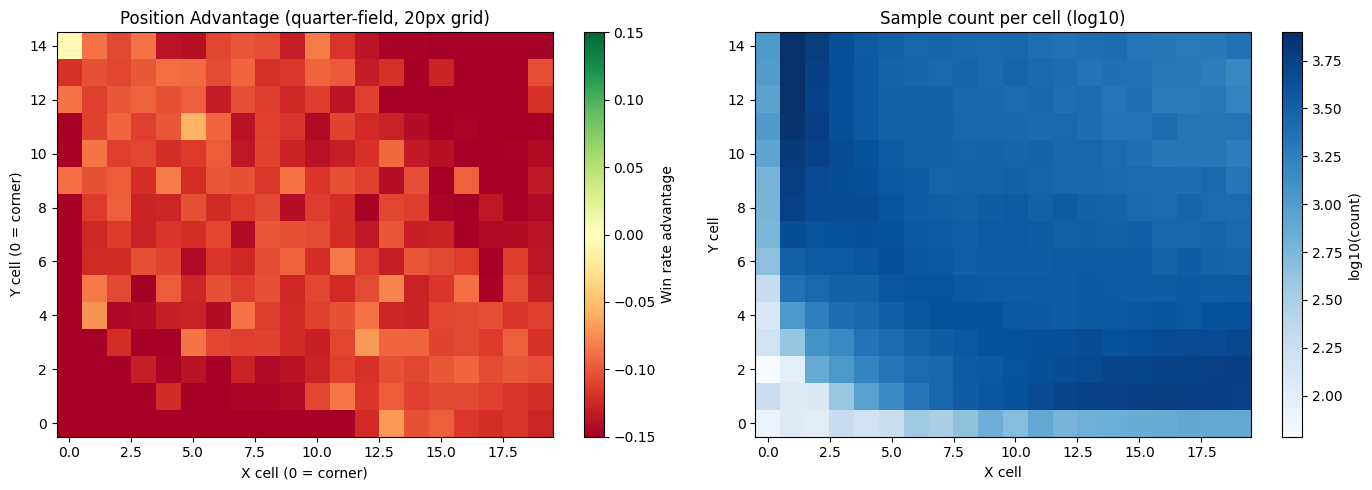


Corner cell (0,0) advantage: -0.500
Center cell (19,14) advantage: -0.247


In [9]:
if has_pos:
    # Attach round outcome to ticks
    # We need to know who won each round
    round_outcomes = scores.groupby(['battle_id', 'robot_name', 'round']).agg(
        win_rate=('win_rate', 'last')
    ).reset_index()

    # For each tick, determine if the observer won this round
    # Approximate: use win_rate > 0.5 at round end as "winning"
    # More precise: join on battle_id + observer_bot + round
    ticks_with_outcome = ticks.merge(
        round_outcomes,
        on=['battle_id', 'round'],
        how='left',
        suffixes=('', '_score')
    )

    # won = 1 if win_rate increased (won this round), else 0
    # Simpler: if energy_ratio > 0.5 at last tick of the round, assume winning
    # Actually, let's use the scores data more directly
    # For now, use energy_ratio > 0.5 as a proxy
    ticks_with_outcome['is_winning'] = (ticks_with_outcome['energy_ratio'] > 0.5).astype(float)

    # Compute per-cell win rate (all bots combined first)
    cells_x = ticks_with_outcome['our_x'].apply(lambda x: to_quarter_cell(x, 0)[0])
    cells_y = ticks_with_outcome['our_y'].apply(lambda y: to_quarter_cell(0, y)[1])
    ticks_with_outcome['cell_x'] = cells_x
    ticks_with_outcome['cell_y'] = cells_y

    # Global heatmap (all opponents)
    global_heatmap = ticks_with_outcome.groupby(['cell_x', 'cell_y'])['is_winning'].agg(['mean', 'count']).reset_index()

    # Create grid
    heatmap_grid = np.full((GRID_H, GRID_W), 0.5)
    count_grid = np.zeros((GRID_H, GRID_W))
    for _, row in global_heatmap.iterrows():
        cx, cy = int(row['cell_x']), int(row['cell_y'])
        if 0 <= cx < GRID_W and 0 <= cy < GRID_H:
            heatmap_grid[cy, cx] = row['mean']
            count_grid[cy, cx] = row['count']

    # Normalize to advantage: subtract 0.5 so 0 = neutral
    advantage_grid = heatmap_grid - 0.5

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im1 = axes[0].imshow(advantage_grid, cmap='RdYlGn', vmin=-0.15, vmax=0.15,
                          origin='lower', aspect='auto')
    axes[0].set_title(f'Position Advantage (quarter-field, {GRID}px grid)')
    axes[0].set_xlabel('X cell (0 = corner)')
    axes[0].set_ylabel('Y cell (0 = corner)')
    plt.colorbar(im1, ax=axes[0], label='Win rate advantage')

    im2 = axes[1].imshow(np.log10(count_grid + 1), cmap='Blues',
                          origin='lower', aspect='auto')
    axes[1].set_title('Sample count per cell (log10)')
    axes[1].set_xlabel('X cell')
    axes[1].set_ylabel('Y cell')
    plt.colorbar(im2, ax=axes[1], label='log10(count)')

    plt.tight_layout()
    plt.show()

    print(f"\nCorner cell (0,0) advantage: {advantage_grid[0, 0]:.3f}")
    print(f"Center cell ({GRID_W-1},{GRID_H-1}) advantage: {advantage_grid[GRID_H-1, GRID_W-1]:.3f}")
else:
    print("Skipping heatmap computation — no position data available.")
    advantage_grid = np.zeros((GRID_H, GRID_W))

In [10]:
if has_pos and 'opponent_bot' in ticks_with_outcome.columns:
    # Per-archetype heatmaps (if archetypes are assigned)
    # Group opponents by archetype, compute separate heatmaps
    if cluster_to_archetype:
        # Map opponent_bot → archetype
        opp_archetype = profiles.set_index('opponent_bot')['archetype_name']
        ticks_with_outcome['opp_archetype'] = ticks_with_outcome['opponent_bot'].map(opp_archetype)

        fig, axes = plt.subplots(2, 4, figsize=(20, 8))
        for idx, arch_name in enumerate(ARCHETYPE_NAMES[1:]):  # Skip UNRECOGNIZED
            if idx >= 8:
                break
            ax = axes[idx // 4, idx % 4]
            subset = ticks_with_outcome[ticks_with_outcome['opp_archetype'] == arch_name]
            if len(subset) < 100:
                ax.set_title(f'{arch_name}\n(n={len(subset)}, insufficient)')
                continue

            arch_grid = np.full((GRID_H, GRID_W), 0.0)
            arch_counts = subset.groupby(['cell_x', 'cell_y'])['is_winning'].agg(['mean', 'count']).reset_index()
            for _, row in arch_counts.iterrows():
                cx, cy = int(row['cell_x']), int(row['cell_y'])
                if 0 <= cx < GRID_W and 0 <= cy < GRID_H:
                    arch_grid[cy, cx] = row['mean'] - 0.5

            im = ax.imshow(arch_grid, cmap='RdYlGn', vmin=-0.2, vmax=0.2,
                          origin='lower', aspect='auto')
            ax.set_title(f'{arch_name}\n(n={len(subset):,})')

        plt.suptitle('Position advantage by opponent archetype', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Archetypes not yet mapped — per-archetype heatmaps skipped.")
        print("  Fill in cluster_to_archetype mapping in cell 10 above.")

⚠ Archetypes not yet mapped — per-archetype heatmaps skipped.
  Fill in cluster_to_archetype mapping in cell 10 above.


## 6. Export: Java Lookup Table Data

Generate the data for `OpponentProfileData.java` — a hardcoded lookup table
indexed by `OPPONENT_BOT_ID_HASH` (FNV-1a of the bot family name).

In [11]:
def fnv1a_32(s):
    """FNV-1a 32-bit hash (matches Java implementation in IdentityFeatures)."""
    h = 0x811c9dc5
    for b in s.encode('utf-8'):
        h ^= b
        h = (h * 0x01000193) & 0xFFFFFFFF
    # Convert to signed int32
    if h >= 0x80000000:
        h -= 0x100000000
    return h

# Build the export table
export_rows = []
for _, row in profiles.iterrows():
    bot = row['opponent_bot']
    # Extract family name (part before first space)
    parts = bot.split(' ', 1)
    family = parts[0]
    bot_id_hash = fnv1a_32(family)

    strength = bot_strength.loc[bot, 'strength'] if bot in bot_strength.index else 0.5
    archetype = int(row.get('archetype', 0))

    export_rows.append({
        'bot': bot,
        'family': family,
        'hash': bot_id_hash,
        'archetype': archetype,
        'strength': round(float(strength), 3),
    })

export_df = pd.DataFrame(export_rows).sort_values('strength', ascending=False)
print("=== Export Table (top 20) ===")
print(export_df.head(20).to_string(index=False))
print(f"\nTotal: {len(export_df)} bots")

=== Export Table (top 20) ===
                        bot      family        hash  archetype  strength
               BeepBoop 2.0    BeepBoop  1755924737          0     0.966
ScalarR 0.005h.053-noshield     ScalarR  1557836413          0     0.909
           Firestarter 2.0f Firestarter  1049467256          0     0.792
              Knight 0.6.28      Knight  -854117796          0     0.783
              DrussGT 3.1.7     DrussGT     3019171          0     0.774
            Dookious 1.573c    Dookious  2029393366          0     0.714
              Combat 3.25.0      Combat  1701925185          0     0.712
            WhiteFang 2.8.1   WhiteFang -1728310464          0     0.691
              Roborio 1.2.4     Roborio  1410933869          0     0.640
         GresSuffurd 0.4.13 GresSuffurd   340336945          0     0.629
                  Pris 0.92        Pris  1127004251          0     0.621
           Neuromancer 7.12 Neuromancer  1666235258          0     0.613
                Tomca

In [12]:
# Print as Java source snippet for OpponentProfileData.java
print("// Auto-generated by notebook 15")
print("// {bot_id_hash, archetype_ordinal, strength_x1000}")
print("private static final int[][] PROFILES = {")
for _, row in export_df.iterrows():
    h = int(row['hash'])
    a = int(row['archetype'])
    s = int(row['strength'] * 1000)
    print(f"    {{{h}, {a}, {s}}},  // {row['bot']}")
print("};")

// Auto-generated by notebook 15
// {bot_id_hash, archetype_ordinal, strength_x1000}
private static final int[][] PROFILES = {
    {1755924737, 0, 966},  // BeepBoop 2.0
    {1557836413, 0, 909},  // ScalarR 0.005h.053-noshield
    {1049467256, 0, 792},  // Firestarter 2.0f
    {-854117796, 0, 783},  // Knight 0.6.28
    {3019171, 0, 774},  // DrussGT 3.1.7
    {2029393366, 0, 714},  // Dookious 1.573c
    {1701925185, 0, 712},  // Combat 3.25.0
    {-1728310464, 0, 691},  // WhiteFang 2.8.1
    {1410933869, 0, 640},  // Roborio 1.2.4
    {340336945, 0, 629},  // GresSuffurd 0.4.13
    {1127004251, 0, 621},  // Pris 0.92
    {1666235258, 0, 613},  // Neuromancer 7.12
    {-2073002563, 0, 600},  // Tomcat 3.68
    {257300171, 0, 589},  // Holden 1.13a
    {1090958013, 0, 577},  // Raven 3.56j8
    {-547800249, 0, 569},  // Diamond 1.8.22
    {-504377433, 0, 549},  // Saguaro 1.0
    {-1156995412, 0, 549},  // Gilgalad 1.99.5c
    {1005702006, 0, 514},  // Domogled 1.2
    {-784483264, 0

## Summary

| Output | Data | Size |
|---|---|---|
| Archetype per bot | 50 entries × (hash, archetype_ordinal) | ~200 bytes |
| Strength per bot | 50 entries × (hash, strength_int) | ~200 bytes |
| Global position heatmap | 20×15 quarter-field grid | 300 floats = 1.2 KB |
| Per-archetype heatmaps | 8 × 300 cells | 9.6 KB |

**Total embedded data**: ~11 KB — trivially fits in Java bytecode.

### Next steps
1. Fill in `cluster_to_archetype` mapping after inspecting clusters
2. Re-run with enriched CSVs (after CI pipeline completes)
3. Export to `OpponentProfileData.java` (generated, like `EnvelopeData.java`)
4. Wire into `OpponentProfileFeatures` → `StrategyComputer`